In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# train transform with augmentation
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    #transforms.RandomErasing(p=0.2, scale=(0.02, 0.12))
])

# validation/test transform without augmentation
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset

DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Combined Dataset"

# dataset with no transform, only used to determine length and split indices
base_dataset = ImageFolder(root=DATASET_PATH)

# 80/20 split
train_size = int(0.8 * len(base_dataset))
test_size = len(base_dataset) - train_size

train_indices, test_indices = random_split(range(len(base_dataset)), [train_size, test_size])

# create two copies of the dataset with different transforms
train_dataset = ImageFolder(root=DATASET_PATH, transform=train_transform)
test_dataset = ImageFolder(root=DATASET_PATH, transform=test_transform)

# apply the same split indices
train_set = Subset(train_dataset, train_indices.indices)
test_set = Subset(test_dataset, test_indices.indices)

# data loaders
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

# verify
print(train_dataset.classes)
print(len(train_set))
print(len(test_set))

['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
5691
1423


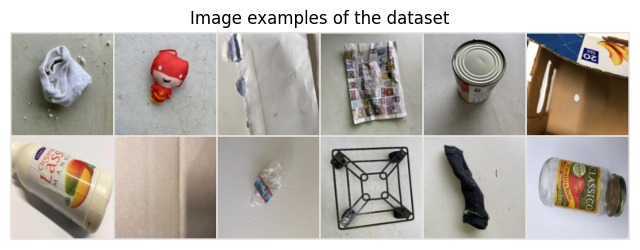

In [ ]:
# Visualize some examples to see if data is loaded correctly
import torch
import matplotlib.pyplot as plt
import torchvision
import numpy as np

NUM_IMAGES = 12
waste_images = torch.stack([train_set[np.random.randint(len(train_set))][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(waste_images, nrow=6, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8,8))
plt.title("Image examples of the dataset")
plt.imshow(img_grid)
plt.axis('off')
plt.show()
plt.close()

based off code from: https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial16/Meta_Learning.ipynb


In [ ]:
#few shot class from example
import random
from collections import defaultdict
#creates episode of N_way classes, with K_shot Images per class, makes model learn to compare classes not memorize labels
#This class turns your dataset into simulated few-shot classification tasks (episodes) instead of normal random batches.
class FewShotBatchSampler(object):

    def __init__(self, dataset_targets, N_way, K_shot, include_query=False, shuffle=True, shuffle_once=False):
        """
        Inputs:
            dataset_targets - PyTorch tensor of the labels of the data elements.
            N_way - Number of classes to sample per batch.
            K_shot - Number of examples to sample per class in the batch.
            include_query - If True, returns batch of size N_way*K_shot*2, which
                            can be split into support and query set. Simplifies
                            the implementation of sampling the same classes but
                            distinct examples for support and query set.
            shuffle - If True, examples and classes are newly shuffled in each
                      iteration (for training)
            shuffle_once - If True, examples and classes are shuffled once in
                           the beginning, but kept constant across iterations
                           (for validation)
        """
        super().__init__()

        self.dataset_targets = dataset_targets
        self.N_way = N_way
        self.K_shot = K_shot
        self.shuffle = shuffle
        self.include_query = include_query
        if self.include_query:
            self.K_shot *= 2
        self.batch_size = self.N_way * self.K_shot  # Number of overall images per batch

        # Organize examples by class
        self.classes = torch.unique(self.dataset_targets).tolist()
        self.num_classes = len(self.classes)
        self.indices_per_class = {}
        self.batches_per_class = {}  # Number of K-shot batches that each class can provide
        for c in self.classes:
            self.indices_per_class[c] = torch.where(self.dataset_targets == c)[0]
            self.batches_per_class[c] = self.indices_per_class[c].shape[0] // self.K_shot

        # Create a list of classes from which we select the N classes per batch
        self.iterations = sum(self.batches_per_class.values()) // self.N_way
        self.class_list = [c for c in self.classes for _ in range(self.batches_per_class[c])]
        if shuffle_once or self.shuffle:
            self.shuffle_data()
        else:
            # For testing, we iterate over classes instead of shuffling them
            sort_idxs = [i+p*self.num_classes for i,
                         c in enumerate(self.classes) for p in range(self.batches_per_class[c])]
            self.class_list = np.array(self.class_list)[np.argsort(sort_idxs)].tolist()

    def shuffle_data(self):
        # Shuffle the examples per class
        for c in self.classes:
            perm = torch.randperm(self.indices_per_class[c].shape[0])
            self.indices_per_class[c] = self.indices_per_class[c][perm]
        # Shuffle the class list from which we sample. Note that this way of shuffling
        # does not prevent to choose the same class twice in a batch. However, for
        # training and validation, this is not a problem.
        random.shuffle(self.class_list)

    def __iter__(self):
        # Shuffle data
        if self.shuffle:
            self.shuffle_data()

        # Sample few-shot batches
        start_index = defaultdict(int)
        for it in range(self.iterations):
            class_batch = self.class_list[it*self.N_way:(it+1)*self.N_way]  # Select N classes for the batch
            index_batch = []
            for c in class_batch:  # For each class, select the next K examples and add them to the batch
                index_batch.extend(self.indices_per_class[c][start_index[c]:start_index[c]+self.K_shot])
                start_index[c] += self.K_shot
            if self.include_query:  # If we return support+query set, sort them so that they are easy to split
                index_batch = index_batch[::2] + index_batch[1::2]
            yield index_batch

    def __len__(self):
        return self.iterations

In [ ]:
N_WAY = 6          # 3 waste classes
K_SHOT = 5       # example: k-shot learning

In [ ]:
from torch.utils import data
#loads images from set but not as batched instead as episodes

# Create a target tensor for the train_set by mapping indices to original dataset targets
train_set_targets = torch.tensor([train_set.dataset.targets[i] for i in train_set.indices])

train_loader = data.DataLoader(
    train_set,
    batch_sampler=FewShotBatchSampler(
        dataset_targets=train_set_targets,
        N_way=N_WAY,
        K_shot=K_SHOT,
        include_query=True,
        shuffle=True
    ),
    num_workers=4
)

In [ ]:
test_set_targets = torch.tensor([test_set.dataset.targets[i] for i in test_set.indices])

test_loader = data.DataLoader(
    test_set,
    batch_sampler=FewShotBatchSampler(
        dataset_targets=test_set_targets,
        N_way=N_WAY,
        K_shot=K_SHOT,
        include_query=True,
        shuffle=False,
        shuffle_once=True
    ),
    num_workers=4
)

In [ ]:
#split a few-shot episode into query and support set
def split_batch(imgs, targets):
    support_imgs, query_imgs = imgs.chunk(2, dim=0)
    support_targets, query_targets = targets.chunk(2, dim=0)
    return support_imgs, query_imgs, support_targets, query_targets

In [ ]:
#Loads images int variables

imgs, targets = next(iter(train_loader))
support_imgs, query_imgs, support_targets, query_targets = split_batch(imgs, targets)

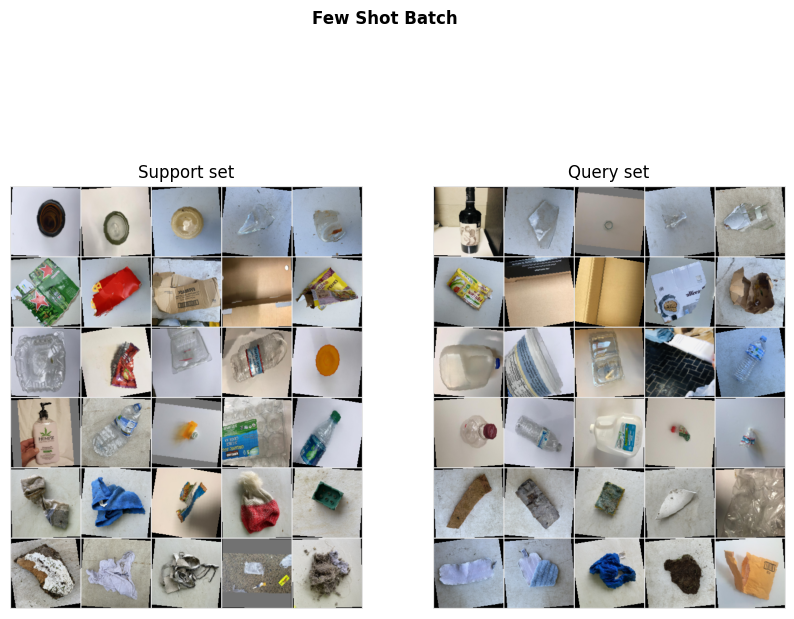

In [ ]:
#visualize results, should have 2 examples of each of the 3 classes
support_grid = torchvision.utils.make_grid(support_imgs, nrow=K_SHOT, normalize=True, pad_value=0.9)
support_grid = support_grid.permute(1, 2, 0)
query_grid = torchvision.utils.make_grid(query_imgs, nrow=K_SHOT, normalize=True, pad_value=0.9)
query_grid = query_grid.permute(1, 2, 0)

fig, ax = plt.subplots(1, 2, figsize=(10, 8))
ax[0].imshow(support_grid)
ax[0].set_title("Support set")
ax[0].axis('off')
ax[1].imshow(query_grid)
ax[1].set_title("Query set")
ax[1].axis('off')
plt.suptitle("Few Shot Batch", weight='bold')
plt.show()
plt.close()

In [ ]:
#This function builds a MobileNet CNN output size equals embedding dimension for few-shot learning.
!pip install pytorch_lightning
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

def get_convnet(output_size, pretrained=True):
    weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
    model = models.mobilenet_v3_small(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, output_size)
    return model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 80.7 MB/s eta 0:00:00


In [ ]:
#defines your Prototypical Network model using PyTorch Lightning It organizes training, validation, optimization, and logging automatically.


# PyTorch Lightning, not in colab so will likly have to install
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint


class ProtoNet(pl.LightningModule):
    def __init__(self, proto_dim, lr):
        super().__init__()
        self.save_hyperparameters()
        self.model = get_convnet(output_size=self.hparams.proto_dim)

        # history containers
        self.train_acc_history = []
        self.val_acc_history = []
        self.train_loss_history = []
        self.val_loss_history = []

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',      # use 'max' if monitoring validation accuracy
            factor=0.5,      # reduce lr by half
            patience=3,      # wait 4 epochs without improvement
            min_lr=1e-6)

        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler,"monitor": "val_loss"}}

    @staticmethod
    def calculate_prototypes(features, targets):
        classes, _ = torch.unique(targets).sort()
        prototypes = []
        for c in classes:
            p = features[torch.where(targets == c)[0]].mean(dim=0)
            prototypes.append(p)
        prototypes = torch.stack(prototypes, dim=0)
        return prototypes, classes

    def classify_feats(self, prototypes, classes, feats, targets):
        dist = torch.pow(prototypes[None, :] - feats[:, None], 2).sum(dim=2)
        preds = F.log_softmax(-dist, dim=1)
        labels = (classes[None, :] == targets[:, None]).long().argmax(dim=-1)
        acc = (preds.argmax(dim=1) == labels).float().mean()
        return preds, labels, acc

    def calculate_loss(self, batch, mode):
        imgs, targets = batch
        features = self.model(imgs)
        support_feats, query_feats, support_targets, query_targets = split_batch(features, targets)
        prototypes, classes = ProtoNet.calculate_prototypes(support_feats, support_targets)
        preds, labels, acc = self.classify_feats(prototypes, classes, query_feats, query_targets)
        loss = F.cross_entropy(preds, labels)

        self.log(f"{mode}_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log(f"{mode}_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self.calculate_loss(batch, mode="train")

    def validation_step(self, batch, batch_idx):
        self.calculate_loss(batch, mode="val")

    def on_train_epoch_end(self):
        metrics = self.trainer.callback_metrics
        if "train_acc" in metrics:
            self.train_acc_history.append(metrics["train_acc"].item())
        if "train_loss" in metrics:
            self.train_loss_history.append(metrics["train_loss"].item())

    def on_validation_epoch_end(self):
        metrics = self.trainer.callback_metrics
        if "val_acc" in metrics:
            self.val_acc_history.append(metrics["val_acc"].item())
        if "val_loss" in metrics:
            self.val_loss_history.append(metrics["val_loss"].item())

    def forward(self, support_imgs, support_targets, query_imgs):
        support_feats = self.model(support_imgs)
        query_feats = self.model(query_imgs)

        prototypes, classes = self.calculate_prototypes(support_feats, support_targets)
        preds, _, _ = self.classify_feats(
            prototypes,
            classes,
            query_feats,
            support_targets.new_zeros(query_imgs.size(0))
        )
        return preds

In [ ]:
# Import tensorboard
%load_ext tensorboard

# Path to the folder where the datasets are/should be downloaded (e.g. CIFAR10)
DATASET_PATH = "../data"
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "../saved_models/tutorial16"

# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Device: cuda:0


In [ ]:
#trains prtoNet model and return best version
def train_model(model_class, train_loader, val_loader, **kwargs):
    trainer = pl.Trainer(
        default_root_dir=os.path.join(CHECKPOINT_PATH, model_class.__name__),
        accelerator="auto",
        devices=1,
        max_epochs=40,
        callbacks=[
            ModelCheckpoint(save_weights_only=True, mode="max", monitor="val_acc"),
            LearningRateMonitor("epoch")
        ],
        enable_progress_bar=True
    )

    pl.seed_everything(42)
    model = model_class(**kwargs)

    trainer.fit(model, train_loader, val_loader)

    # keep history from trained model
    trained_model = model

    # load best checkpoint separately
    best_model = model_class.load_from_checkpoint(
        trainer.checkpoint_callback.best_model_path
    )

    return trained_model, best_model

In [ ]:
#train model, dont need to run if model already trained and saved
import torch.optim as optim
import torch.nn.functional as F
import os
protonet_model = train_model(
    ProtoNet,
    train_loader=train_loader,
    val_loader=test_loader,  # use test as validation
    proto_dim=64, #each image becomes 64 dims
    lr=2e-4 #set learning rate
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MobileNetV3 │  1.6 M │ train │     0 │
└───┴───────┴─────────────┴────────┴───────┴───────┘

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 209                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=40` reached.


In [ ]:
#save model to drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
trained_model, best_model = protonet_model
protonet_model = trained_model

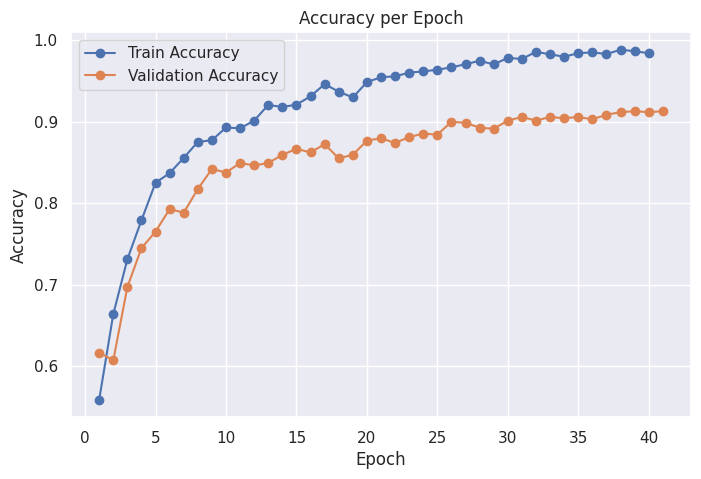

In [ ]:
import matplotlib.pyplot as plt

model_to_plot = protonet_model

train_epochs = range(1, len(model_to_plot.train_acc_history) + 1)
val_epochs = range(1, len(model_to_plot.val_acc_history) + 1)

plt.figure(figsize=(8,5))
plt.plot(train_epochs, model_to_plot.train_acc_history, marker='o', label='Train Accuracy')
plt.plot(val_epochs, model_to_plot.val_acc_history, marker='o', label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import torch
save_path = "/content/drive/MyDrive/Colab Notebooks/MobileNet_LessDataAugmented_LrPlateau.ckpt"
torch.save(protonet_model.state_dict(), save_path)

print("Model saved to Google Drive!")

Model saved to Google Drive!


In [ ]:
#load model
# Recreate the model architecture
model = ProtoNet(proto_dim=64, lr=2e-4)

# Load saved weights
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/MobileNet_LessDataAugmented_LrPlateau.ckpt"))

protonet_model = model

In [ ]:
###EVALUATING THE MODEL
import time
model.eval()
with torch.no_grad():
    start = time.time()
    output = model(support_imgs, support_targets, query_imgs)
    end = time.time()
print(f"Inference Time: {(end-start)*1000:.2f} ms")

# PyTorch example
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/MobileNet_LessDataAugmented_LrPlateau.ckpt"))
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()
size_all_mb = (param_size + buffer_size) / 1024**2
print(f'Model size: {size_all_mb:.2f} MB')

Inference Time: 21.95 ms
Model size: 6.09 MB


In [ ]:
import torch
from tqdm.auto import tqdm
from statistics import mean, stdev
from torch.utils import data

@torch.no_grad()
def test_proto_net_fixed(model, dataset, data_feats=None, k_shot=4, num_trials=50, device='cuda'):
    model = model.to(device)
    model.eval()

    # Extract features once
    if data_feats is None:
        dataloader = data.DataLoader(dataset, batch_size=128, num_workers=4, shuffle=False, drop_last=False)

        img_features = []
        img_targets = []

        for imgs, targets in tqdm(dataloader, desc="Extracting image features", leave=False):
            imgs = imgs.to(device)
            feats = model.model(imgs)
            img_features.append(feats.detach().cpu())
            img_targets.append(targets.cpu())

        img_features = torch.cat(img_features, dim=0)
        img_targets = torch.cat(img_targets, dim=0)
    else:
        img_features, img_targets = data_feats

    # Get class IDs
    class_ids = torch.unique(img_targets)

    # Store indices per class
    class_to_indices = {}
    for c in class_ids:
        class_indices = torch.where(img_targets == c)[0]
        class_to_indices[int(c.item())] = class_indices

    # Check k validity
    min_class_count = min(len(v) for v in class_to_indices.values())
    if k_shot >= min_class_count:
        raise ValueError(
            f"k_shot={k_shot} is too large. Smallest class has only {min_class_count} samples, "
            f"so you need at least 1 query sample left."
        )

    accuracies = []

    for _ in tqdm(range(num_trials), desc=f"Evaluating {k_shot}-shot", leave=False):
        support_indices = []
        query_indices = []

        # Random support/query split per class
        for c in class_ids:
            c_int = int(c.item())
            indices = class_to_indices[c_int]
            perm = indices[torch.randperm(len(indices))]

            support_indices.append(perm[:k_shot])
            query_indices.append(perm[k_shot:])

        support_indices = torch.cat(support_indices)
        query_indices = torch.cat(query_indices)

        support_feats = img_features[support_indices]
        support_targets = img_targets[support_indices]

        query_feats = img_features[query_indices]
        query_targets = img_targets[query_indices]

        prototypes, proto_classes = model.calculate_prototypes(support_feats, support_targets)
        _, _, acc = model.classify_feats(prototypes, proto_classes, query_feats, query_targets)

        accuracies.append(acc.item())

    return (mean(accuracies), stdev(accuracies)), (img_features, img_targets)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_few_shot(acc_dict, name, color=None, ax=None):
    sns.set()
    if ax is None:
        fig, ax = plt.subplots(1,1,figsize=(5,3))
    ks = sorted(list(acc_dict.keys()))
    mean_accs = [acc_dict[k][0] for k in ks]
    std_accs = [acc_dict[k][1] for k in ks]
    ax.plot(ks, mean_accs, marker='o', markeredgecolor='k', markersize=6, label=name, color=color)
    ax.fill_between(ks, [m-s for m,s in zip(mean_accs, std_accs)], [m+s for m,s in zip(mean_accs, std_accs)], alpha=0.2, color=color)
    ax.set_xticks(ks)
    ax.set_xlim([ks[0]-1, ks[-1]+1])
    ax.set_xlabel("Number of shots per class", weight='bold')
    ax.set_ylabel("Accuracy", weight='bold')
    if len(ax.get_title()) == 0:
        ax.set_title("Few-Shot Performance " + name, weight='bold')
    else:
        ax.set_title(ax.get_title() + " and " + name, weight='bold')
    ax.legend()
    return ax

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(true_labels, predicted_labels, class_names, title="Confusion Matrix", figsize=(8, 6)):
    """
    Plots a confusion matrix.

    Args:
        true_labels (torch.Tensor or np.array): Ground truth labels.
        predicted_labels (torch.Tensor or np.array): Predicted labels.
        class_names (list): List of class names.
        title (str): Title of the plot.
        figsize (tuple): Figure size for the plot.
    """
    cm = confusion_matrix(true_labels, predicted_labels, labels=np.arange(len(class_names)))
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=figsize)
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()
    plt.close()

In [ ]:
@torch.no_grad()
def get_predictions_proto_net(model, dataset, k_shot=4):
    model = model.to(device)
    model.eval()

    dataloader = data.DataLoader(dataset, batch_size=128, shuffle=False)

    all_features = []
    all_targets = []

    # Extract features
    for imgs, targets in dataloader:
        imgs = imgs.to(device)
        feats = model.model(imgs)
        all_features.append(feats.cpu())
        all_targets.append(targets)

    features = torch.cat(all_features, dim=0)
    targets = torch.cat(all_targets, dim=0)

    # Compute prototypes using first k_shot per class
    unique_classes = torch.unique(targets)
    prototypes = []
    proto_classes = []

    for c in unique_classes:
        class_indices = torch.where(targets == c)[0]
        support_indices = class_indices[:k_shot]
        proto = features[support_indices].mean(dim=0)
        prototypes.append(proto)
        proto_classes.append(c)

    prototypes = torch.stack(prototypes)
    proto_classes = torch.stack(proto_classes)

    # Classify ALL samples
    dist = torch.pow(prototypes[None, :] - features[:, None], 2).sum(dim=2)
    preds = torch.argmax(-dist, dim=1)

    # Map indices back to original class labels
    predicted_labels = proto_classes[preds]

    return targets.numpy(), predicted_labels.numpy()

In [ ]:
@torch.no_grad()
def test_avg_confidence(model, dataloader, device='cuda'):
    model = model.to(device)
    model.eval()

    class_confidences = defaultdict(list)

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass to get features from the model's encoder
        features = model.model(images)

        # Get all training features and targets to form global prototypes
        all_train_features = []
        all_train_targets = []
        train_dataloader_full = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=False, num_workers=2)
        for t_imgs, t_targets in train_dataloader_full:
            t_imgs = t_imgs.to(device)
            t_feats = model.model(t_imgs)
            all_train_features.append(t_feats.detach().cpu())
            all_train_targets.append(t_targets)
        all_train_features = torch.cat(all_train_features, dim=0).to(device)
        all_train_targets = torch.cat(all_train_targets, dim=0).to(device)

        global_prototypes, global_classes = ProtoNet.calculate_prototypes(all_train_features, all_train_targets)

        # Now use these global prototypes to classify the test images and get confidence
        feats = model.model(images)
        preds_logits, actual_labels_for_loss, acc = model.classify_feats(global_prototypes, global_classes, feats, labels)

        # Convert log_softmax to probabilities
        probs = torch.exp(preds_logits)

        # Get the predicted class (index relative to global_classes)
        predicted_indices = torch.argmax(probs, dim=1)

        # Get the confidence (probability of the predicted class)
        conf = probs.gather(1, predicted_indices.unsqueeze(1)).squeeze()

        # Store confidence by the *true* class label for averaging
        for i in range(len(labels)):
            class_confidences[labels[i].item()].append(conf[i].item())

    # Compute averages
    avg_conf = {}
    for cls in class_confidences:
        if class_confidences[cls]: # Ensure there are confidences for the class
            avg_conf[cls] = sum(class_confidences[cls]) / len(class_confidences[cls])
        else:
            avg_conf[cls] = 0.0 # Or some other default if no predictions for a class

    return avg_conf

# Define class names using the test_set
class_names = test_set.dataset.classes

# Call the function to get average confidences
avg_conf = test_avg_confidence(protonet_model, test_loader, device)

print("Average confidence of predictions for each class:")
for cls_idx, conf in avg_conf.items():
    # Ensure cls_idx is within bounds of class_names
    if cls_idx < len(class_names):
        print(f"{class_names[cls_idx]}: {conf:.3f}")
    else:
        print(f"Class {cls_idx} (Unknown): {conf:.3f}")

Average confidence of predictions for each class:
cardboard: 0.952
glass: 0.946
compost: 0.990
paper: 0.951
metal: 0.957
trash: 0.931
plastic: 0.943


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 2-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=2: 80.57% (+-5.28%)


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 4-shot:   0%|          | 0/50 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a5d2499dd00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a5d2499dd00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]


  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^Exception ignored in: ^^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a5d2499dd00>^
^^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^^ ^
 AssertionError :  can only test a child process 
  ^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a5d2499dd00>^
^^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "

Evaluating 30-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=30: 88.12% (+-0.40%)


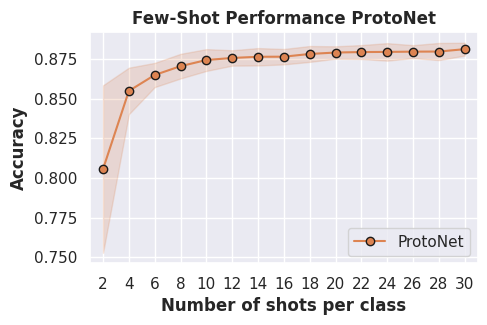

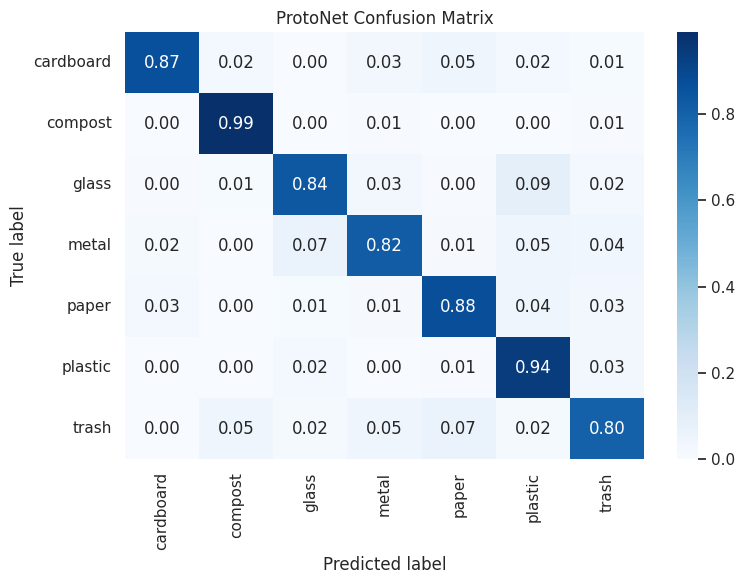

In [ ]:
#load model
# Recreate the model architecture
model = ProtoNet(proto_dim=64, lr=2e-4)

# Load saved weights
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/MobileNet_LessDataAugmented_LrPlateau.ckpt"))

MobileModel = model

import torch.optim as optim
import torch.nn.functional as F
import os
protonet_accuracies = dict()
data_feats = None
for k in range(2,31,2):# test at these different numers of support samples per class
    protonet_accuracies[k], data_feats = test_proto_net_fixed(MobileModel, test_set, k_shot=k) ###INSTEAD OF USING test_proto_net just use the variable test_set and do a forward pass of the model to evaluate
    print(f"Accuracy for k={k}: {100.0*protonet_accuracies[k][0]:4.2f}% (+-{100*protonet_accuracies[k][1]:4.2f}%)")

ax = plot_few_shot(protonet_accuracies, name="ProtoNet", color="C1")
plt.show()
plt.close()

#get and store labels
true_labels, predicted_labels = get_predictions_proto_net(
    MobileModel,
    test_set,
    K_SHOT
)

#call conf_matrix  function
plot_confusion_matrix(
    true_labels,
    predicted_labels,
    test_set.dataset.classes,
    title="ProtoNet Confusion Matrix"
)

In [ ]:
import copy
import os
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from torch.ao.quantization import quantize_dynamic

CKPT_PATH = "/content/drive/MyDrive/Colab Notebooks/all models/MobileNet_LessDataAugmented_LrPlateau.ckpt"
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/all models/pruned_quantized_outputs"
PRUNE_AMOUNT = 0.20

os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Recreate the model architecture exactly as before
original_model = ProtoNet(
    proto_dim=64,          # use the values you trained with
    lr=2e-4,
)

# 2. Load the weights file
state_dict = torch.load(CKPT_PATH, map_location="cpu", weights_only=True)
original_model.load_state_dict(state_dict)
original_model.eval()

# 3. Make a copy so the original model in memory stays unchanged
pruned_model = copy.deepcopy(original_model)
pruned_model.eval()

# 4. Prune only the copy
for module in pruned_model.model.modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        prune.l1_unstructured(module, name="weight", amount=PRUNE_AMOUNT)

# 5. Make pruning permanent
for module in pruned_model.model.modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        try:
            prune.remove(module, "weight")
        except ValueError:
            pass

pruned_model.eval()

# 6. Copy the pruned model for quantization
quantized_model = copy.deepcopy(pruned_model)
quantized_model.eval()

# 7. Dynamic quantization (mostly affects Linear layers)
quantized_model.model = quantize_dynamic(
    quantized_model.model,
    {nn.Linear},
    dtype=torch.qint8
)

quantized_model.eval()

# 8. Save new files
#torch.save(original_model.state_dict(), os.path.join(SAVE_DIR, "original_model_state_dict.ckpt"))
#torch.save(pruned_model.state_dict(), os.path.join(SAVE_DIR, "pruned_model_state_dict.ckpt"))
#torch.save(quantized_model.state_dict(), os.path.join(SAVE_DIR, "pruned_quantized_model_state_dict.ckpt"))

#print("Done.")
#print(os.path.join(SAVE_DIR, "original_model_state_dict.ckpt"))
#print(os.path.join(SAVE_DIR, "pruned_model_state_dict.ckpt"))
#print(os.path.join(SAVE_DIR, "pruned_quantized_model_state_dict.ckpt"))

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 144MB/s]
/tmp/ipykernel_3436/722725730.py:49: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model.model = quantize_dynamic(


ProtoNet(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): Conv2dNor

In [ ]:
import os

def get_file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)

orig_path  = os.path.join(SAVE_DIR, "original_model_state_dict.ckpt")
prune_path = os.path.join(SAVE_DIR, "pruned_model_state_dict.ckpt")
quant_path = os.path.join(SAVE_DIR, "pruned_quantized_model_state_dict.ckpt")

print(f"Original size:         {get_file_size_mb(orig_path):.2f} MB")
print(f"Pruned size:           {get_file_size_mb(prune_path):.2f} MB")
print(f"Pruned + quant size:   {get_file_size_mb(quant_path):.2f} MB")

Original size:         6.17 MB
Pruned size:           6.17 MB
Pruned + quant size:   4.30 MB


In [ ]:
import torch

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_sparsity(model):
    total_elems = 0
    zero_elems = 0

    for name, param in model.named_parameters():
        if "weight" in name:
            total_elems += param.numel()
            zero_elems += (param == 0).sum().item()

    sparsity = 100.0 * zero_elems / total_elems if total_elems > 0 else 0.0
    return sparsity

for name, m in {
    "original": original_model,
    "pruned": pruned_model,
    "quantized": quantized_model
}.items():
    total, trainable = count_parameters(m)
    print(f"{name}: total params = {total:,}, trainable = {trainable:,}, sparsity = {model_sparsity(m):.2f}%")

original: total params = 1,583,456, trainable = 1,583,456, sparsity = 0.00%
pruned: total params = 1,583,456, trainable = 1,583,456, sparsity = 9.96%
quantized: total params = 927,008, trainable = 927,008, sparsity = 9.93%


In [ ]:
# original
orig_model = ProtoNet(proto_dim=64, lr=2e-4)
orig_model.load_state_dict(torch.load(orig_path, map_location="cpu", weights_only=True))
orig_model.eval()

# pruned
pruned_model = ProtoNet(proto_dim=64, lr=2e-4)
pruned_model.load_state_dict(torch.load(prune_path, map_location="cpu", weights_only=True))
pruned_model.eval()

# quantized
quant_model = ProtoNet(proto_dim=64, lr=2e-4)
quant_model.load_state_dict(torch.load(prune_path, map_location="cpu", weights_only=True))
quant_model.model = quantize_dynamic(quant_model.model, {nn.Linear}, dtype=torch.qint8)
quant_model.load_state_dict(torch.load(quant_path, map_location="cpu", weights_only=True))
quant_model.eval()

/tmp/ipykernel_767/1892106859.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quant_model.model = quantize_dynamic(quant_model.model, {nn.Linear}, dtype=torch.qint8)


ProtoNet(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): Conv2dNor

In [ ]:
quantized_model = ProtoNet(proto_dim=64, lr=2e-4)
quantized_model.model = quantize_dynamic(
    quantized_model.model,
    {nn.Linear},
    dtype=torch.qint8
)

quantized_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/Colab Notebooks/all models/pruned_quantized_outputs/pruned_quantized_model_state_dict.ckpt",
    map_location="cpu"
))

/tmp/ipykernel_767/1729411848.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model.model = quantize_dynamic(


<All keys matched successfully>

In [ ]:
import torch
import torch.utils.data as data

@torch.no_grad()
def get_predictions_proto_net_query_only(model, dataset, k_shot=4, batch_size=128, device="cpu"):
    model = model.to(device)
    model.eval()

    dataloader = data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_features = []
    all_targets = []

    # Extract features
    for imgs, targets in dataloader:
        imgs = imgs.to(device)
        feats = model.model(imgs)
        all_features.append(feats.cpu())
        all_targets.append(targets.cpu())

    features = torch.cat(all_features, dim=0)
    targets = torch.cat(all_targets, dim=0)

    unique_classes = torch.unique(targets).sort()[0]

    prototypes = []
    proto_classes = []
    query_indices_all = []

    for c in unique_classes:
        class_indices = torch.where(targets == c)[0]

        # First k_shot are support
        support_indices = class_indices[:k_shot]

        # Remaining are query
        query_indices = class_indices[k_shot:]

        if len(support_indices) < k_shot:
            raise ValueError(f"Class {c.item()} has fewer than k_shot={k_shot} samples.")

        if len(query_indices) == 0:
            continue

        proto = features[support_indices].mean(dim=0)
        prototypes.append(proto)
        proto_classes.append(c)
        query_indices_all.append(query_indices)

    prototypes = torch.stack(prototypes)              # [num_classes, feat_dim]
    proto_classes = torch.stack(proto_classes)        # [num_classes]
    query_indices_all = torch.cat(query_indices_all)  # [num_query_total]

    query_features = features[query_indices_all]      # [Nq, feat_dim]
    true_labels = targets[query_indices_all]          # [Nq]

    # Euclidean distance
    dists = torch.cdist(query_features, prototypes)   # [Nq, num_classes]
    pred_idx = torch.argmin(dists, dim=1)
    predicted_labels = proto_classes[pred_idx]

    return true_labels.numpy(), predicted_labels.numpy()

In [ ]:
@torch.no_grad()
def test_avg_confidence_quant(model, dataloader, device='cpu'):
    model = model.to(device)
    model.eval()

    class_confidences = defaultdict(list)

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass to get features from the model's encoder
        features = model.model(images)

        # Get all training features and targets to form global prototypes
        all_train_features = []
        all_train_targets = []
        train_dataloader_full = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=False, num_workers=2)
        for t_imgs, t_targets in train_dataloader_full:
            t_imgs = t_imgs.to(device)
            t_feats = model.model(t_imgs)
            all_train_features.append(t_feats.detach().cpu())
            all_train_targets.append(t_targets)
        all_train_features = torch.cat(all_train_features, dim=0).to(device)
        all_train_targets = torch.cat(all_train_targets, dim=0).to(device)

        global_prototypes, global_classes = ProtoNet.calculate_prototypes(all_train_features, all_train_targets)

        # Now use these global prototypes to classify the test images and get confidence
        feats = model.model(images)
        preds_logits, actual_labels_for_loss, acc = model.classify_feats(global_prototypes, global_classes, feats, labels)

        # Convert log_softmax to probabilities
        probs = torch.exp(preds_logits)

        # Get the predicted class (index relative to global_classes)
        predicted_indices = torch.argmax(probs, dim=1)

        # Get the confidence (probability of the predicted class)
        conf = probs.gather(1, predicted_indices.unsqueeze(1)).squeeze()

        # Store confidence by the *true* class label for averaging
        for i in range(len(labels)):
            class_confidences[labels[i].item()].append(conf[i].item())

    # Compute averages
    avg_conf = {}
    for cls in class_confidences:
        if class_confidences[cls]: # Ensure there are confidences for the class
            avg_conf[cls] = sum(class_confidences[cls]) / len(class_confidences[cls])
        else:
            avg_conf[cls] = 0.0 # Or some other default if no predictions for a class

    return avg_conf

# Define class names using the test_set
class_names = test_set.dataset.classes

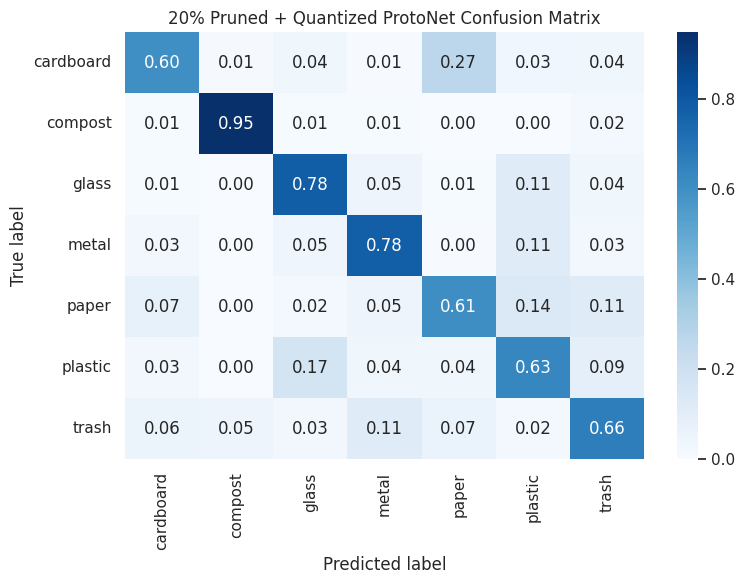

In [ ]:
# Quantized
true_labels_quant, pred_labels_quant = get_predictions_proto_net_query_only(
    quantized_model, test_set, k_shot=K_SHOT, device='cpu')

plot_confusion_matrix(
    true_labels_quant,
    pred_labels_quant,
    test_set.dataset.classes,
    title="20% Pruned + Quantized ProtoNet Confusion Matrix"
)

In [ ]:
# Call the function to get average confidences
avg_conf = test_avg_confidence_quant(quantized_model, test_loader)

print("Average confidence of predictions for each class:")
for cls_idx, conf in avg_conf.items():
    # Ensure cls_idx is within bounds of class_names
    if cls_idx < len(class_names):
        print(f"{class_names[cls_idx]}: {conf:.3f}")
    else:
        print(f"Class {cls_idx} (Unknown): {conf:.3f}")

Average confidence of predictions for each class:
cardboard: 0.864
glass: 0.889
compost: 0.976
paper: 0.862
metal: 0.876
trash: 0.839
plastic: 0.845


In [ ]:
# 6. Copy the pruned model for quantization
ONLYquantized_model = copy.deepcopy(orig_model)
ONLYquantized_model.eval()

# 7. Dynamic quantization (mostly affects Linear layers)
ONLYquantized_model.model = quantize_dynamic(
    ONLYquantized_model.model,
    {nn.Linear},
    dtype=torch.qint8
)

ONLYquantized_model.eval()
for name, m in {
    "original": original_model,
    "pruned": pruned_model,
    "quantized": quantized_model,
    'onlyquant': ONLYquantized_model
}.items():
    total, trainable = count_parameters(m)
    print(f"{name}: total params = {total:,}, trainable = {trainable:,}, sparsity = {model_sparsity(m):.2f}%")

original: total params = 1,583,456, trainable = 1,583,456, sparsity = 0.00%
pruned: total params = 1,583,456, trainable = 1,583,456, sparsity = 9.96%
quantized: total params = 927,008, trainable = 927,008, sparsity = 9.93%
onlyquant: total params = 927,008, trainable = 927,008, sparsity = 0.00%


/tmp/ipykernel_767/3069807161.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  ONLYquantized_model.model = quantize_dynamic(


In [ ]:
torch.save(ONLYquantized_model.state_dict(), os.path.join(SAVE_DIR, "quantized_model_state_dict.ckpt"))
quant_path = os.path.join(SAVE_DIR, "quantized_model_state_dict.ckpt")

In [ ]:
ONLYquantized_model = ProtoNet(proto_dim=64, lr=2e-4)
ONLYquantized_model.model = quantize_dynamic(
    ONLYquantized_model.model,
    {nn.Linear},
    dtype=torch.qint8
)

ONLYquantized_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/Colab Notebooks/all models/pruned_quantized_outputs/quantized_model_state_dict.ckpt",
    map_location="cpu"
))

/tmp/ipykernel_767/3696670252.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  ONLYquantized_model.model = quantize_dynamic(


<All keys matched successfully>

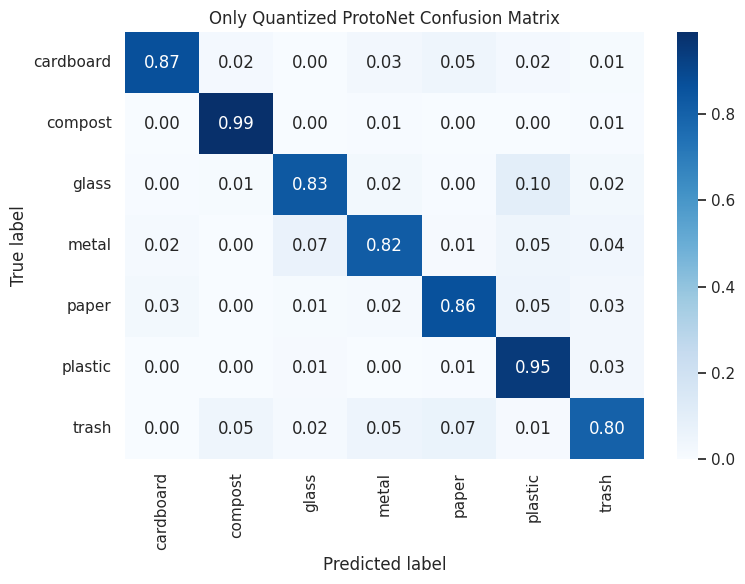

In [ ]:
# Quantized
true_labels_quant, pred_labels_quant = get_predictions_proto_net_query_only(
    ONLYquantized_model, test_set, k_shot=K_SHOT, device='cpu')

plot_confusion_matrix(
    true_labels_quant,
    pred_labels_quant,
    test_set.dataset.classes,
    title="Only Quantized ProtoNet Confusion Matrix"
)

In [ ]:
ONLYquantized_model.eval()
print(f"Quantized size:   {get_file_size_mb(os.path.join(SAVE_DIR, "quantized_model_state_dict.ckpt")):.2f} MB")

Quantized size:   4.30 MB


In [ ]:
# Call the function to get average confidences
avg_conf = test_avg_confidence_quant(ONLYquantized_model, test_loader)

print("Average confidence of predictions for each class:")
for cls_idx, conf in avg_conf.items():
    # Ensure cls_idx is within bounds of class_names
    if cls_idx < len(class_names):
        print(f"{class_names[cls_idx]}: {conf:.3f}")
    else:
        print(f"Class {cls_idx} (Unknown): {conf:.3f}")

Average confidence of predictions for each class:
cardboard: 0.951
glass: 0.947
compost: 0.990
paper: 0.953
metal: 0.957
trash: 0.931
plastic: 0.943


In [ ]:
###EVALUATING THE MODEL
import time

for name, m in {
    "original": original_model,
    "pruned": pruned_model,
    "quantized": quantized_model,
    #'onlyquant': ONLYquantized_model
}.items():
  with torch.no_grad():
      start = time.time()
      output = m(support_imgs, support_targets, query_imgs)
      end = time.time()
  print(f"{name} Inference Time: {(end-start)*1000:.2f} ms")

original Inference Time: 209.09 ms
pruned Inference Time: 64.52 ms
quantized Inference Time: 74.69 ms


In [ ]:
ONLYquantized_model.eval()

ProtoNet(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): Conv2dNor

In [ ]:
MobileModel.eval()

ProtoNet(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): Conv2dNor